In [ ]:
import numpy as np
import pandas as pd

# --- CONFIGURATION: THE THREE ARCHETYPES ---
# Define (Mean Speed, Std Dev, % of Total Field)
ARCHETYPES = [
    (0,  10, 0.15),  # "Low"
    (20, 30, 0.60),  # "Mid"
    (50, 25, 0.25)   # "High"
]

N_PLAYERS = 1000
STEP_SIZE = 0.5

def generate_trinomial_field(archetypes, n_total):
    field = []
    for mu, sigma, weight in archetypes:
        n_group = int(n_total * weight)
        group_speeds = np.random.normal(mu, sigma, n_group)
        field.extend(group_speeds)
    return np.clip(field, 0, 100)

def get_pnl(res_pct, scale_pct, speed_pct, field):
    if res_pct <= 0: res_score = 0
    else: res_score = 200_000 * np.log(1 + res_pct) / np.log(101)
    
    scale_score = (7 / 100) * scale_pct
    
    # Calculate rank against the field
    rank = 1 + np.sum(field > speed_pct)
    total_pool = len(field) + 1
    multiplier = 0.9 - (0.8 * (rank - 1) / (total_pool - 1))
    
    return (res_score * scale_score * multiplier) - (res_pct + scale_pct + speed_pct)

# --- EXECUTION ---
comp_field = generate_trinomial_field(ARCHETYPES, N_PLAYERS)
sim_results = []

for z in np.arange(0, 100 + STEP_SIZE, STEP_SIZE):
    remaining = 100 - z
    best_pnl = -np.inf
    best_x = 0
    
    for x in np.arange(0, remaining + STEP_SIZE, STEP_SIZE):
        y = remaining - x
        pnl = get_pnl(x, y, z, comp_field)
        if pnl > best_pnl:
            best_pnl, best_x = pnl, x
            
    sim_results.append({'speed': z, 'res': best_x, 'scale': remaining-best_x, 'pnl': best_pnl})

# Find the winner
df = pd.DataFrame(sim_results)
best = df.loc[df['pnl'].idxmax()]

print(f"Optimal Allocation for this Tri-modal field:")
print(f"Research: {best['res']:.1f}% | Scale: {best['scale']:.1f}% | Speed: {best['speed']:.1f}%")
print(f"Expected PnL: {best['pnl']:,.2f}")

Optimal Allocation for this Tri-modal field:
Research: 18.5% | Scale: 57.0% | Speed: 24.5%
Expected PnL: 286,702.09


--- OPTIMAL SPLIT (Speed Fixed at 35) ---
Research Allocation: 16.20%
Scale Allocation:    48.80%
Expected PnL:        210,473.26


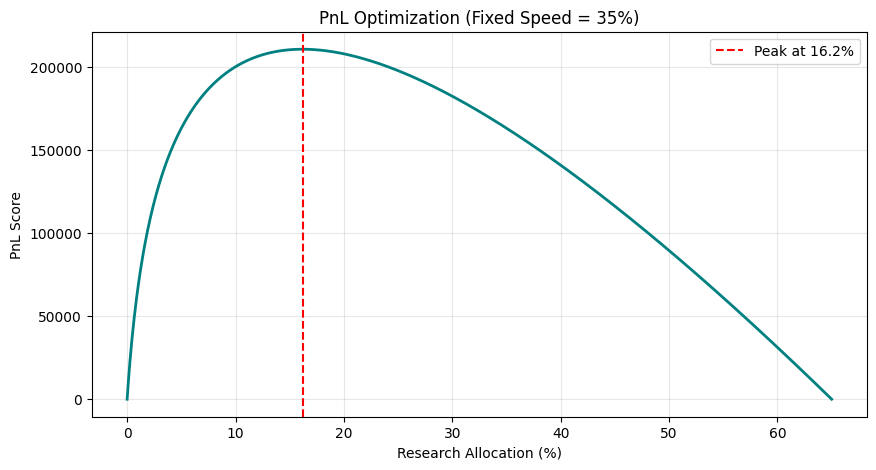

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- SETTINGS ---
FIXED_SPEED = 35
TOTAL_BUDGET = 100
REMAINING = TOTAL_BUDGET - FIXED_SPEED

# The speed multiplier is constant here since speed is fixed 
# (Assuming a middle-of-the-road 0.5 for visualization, but it doesn't change the peak location)
SPEED_MULT = 0.5 

def get_pnl(res_pct):
    scale_pct = REMAINING - res_pct
    
    # Research Score
    res_score = 200_000 * np.log(1 + res_pct) / np.log(101)
    
    # Scale Score
    scale_score = (7 / 100) * scale_pct
    
    # Final PnL
    gross_pnl = res_score * scale_score * SPEED_MULT
    return gross_pnl - TOTAL_BUDGET

# --- OPTIMIZATION ---
res_values = np.linspace(0, REMAINING, 1000)
pnl_values = [get_pnl(r) for r in res_values]

# Find the maximum
best_idx = np.argmax(pnl_values)
best_res = res_values[best_idx]
best_scale = REMAINING - best_res
max_pnl = pnl_values[best_idx]

print(f"--- OPTIMAL SPLIT (Speed Fixed at {FIXED_SPEED}) ---")
print(f"Research Allocation: {best_res:.2f}%")
print(f"Scale Allocation:    {best_scale:.2f}%")
print(f"Expected PnL:        {max_pnl:,.2f}")

# --- VISUALIZATION ---
plt.figure(figsize=(10, 5))
plt.plot(res_values, pnl_values, color='teal', linewidth=2)
plt.axvline(best_res, color='red', linestyle='--', label=f'Peak at {best_res:.1f}%')
plt.title(f'PnL Optimization (Fixed Speed = {FIXED_SPEED}%)')
plt.xlabel('Research Allocation (%)')
plt.ylabel('PnL Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()